<a href="https://colab.research.google.com/github/isabellaecheverri/NumCalc/blob/main/Lecture09/notebooks/L09_CNN_Transfer_pytorch_hf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transferencia de Aprendizaje en el Conjunto de Datos Caltech101

En este cuaderno, consideraremos un conjunto de datos más complejo que MNIST o CIFAR10. Las imágenes en Caltech101 son imágenes RGB (3 canales) con tamaño variable. Hay 101 clases diferentes. Intentaremos una práctica muy común en visión por computadora en la actualidad: transferencia de aprendizaje desde un modelo preentrenado en ImageNet.

## Plan de Trabajo:
- Modificar la red del ejercicio anterior (CIFAR-10) para trabajar con imágenes de 224x224.
- Entrenar el modelo por un tiempo en Caltech101 y ver qué tan lejos podemos llegar.
- Tomar un ResNet34 que fue preentrenado en ImageNet-1k y ajustarlo a Caltech101.
  - Considerar tanto entrenar solo la cabeza (el clasificador lineal al final de la red) como toda la red.
  - Deberíamos poder alcanzar un mejor rendimiento que nuestra red original en menos pasos de entrenamiento.
- Opcional: experimentar con otros modelos preentrenados de `timm` (ver información [aquí](https://github.com/rwightman/pytorch-image-models)).

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

## Preliminares

In [2]:
%matplotlib inline
from typing import List, Optional, Callable, Iterator
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torchvision.models as models

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset, Subset
from datasets import load_dataset
from collections import Counter

sns.set_style("whitegrid")

def show_image(img, title=None):
    img = img.detach().cpu()
    img = img.permute((1, 2, 0)).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean   # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.gca().tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    if title is not None:
        plt.title(title)

## Configuración de la base de datos

In [3]:
# --- ImageNet normalization
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
default_imagenet_normalization = transforms.Normalize(mean=imagenet_mean, std=imagenet_std)

# --- Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.25, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    default_imagenet_normalization,
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    default_imagenet_normalization,
])

# Step 1: Load dataset
hf_dataset = load_dataset("flwrlabs/caltech101", split="train")  # all in one split

# Step 2: Count class occurrences
label_counts = Counter(hf_dataset['label'])

# Step 3: Keep only classes with ≤100 samples
keep_classes = sorted([label for label, count in label_counts.items() if count <= 100])

# Step 4: Subsample max 100 samples per class
indices = list(range(len(hf_dataset)))
random.shuffle(indices)

new_indices = []
class_counts = {i: 0 for i in keep_classes}

for i in indices:
    y = hf_dataset[i]['label']
    if y in keep_classes and class_counts[y] < 100:
        new_indices.append(i)
        class_counts[y] += 1

# Step 5: Translate labels
def translate_label(y, keep_classes):
    try:
        return keep_classes.index(y)
    except ValueError:
        return -1

labels = [translate_label(hf_dataset[i]['label'], keep_classes) for i in new_indices]
assert max(labels) == len(keep_classes) - 1

labels = np.array(labels)
# Step 6: Train-test split
test_size = 640
val_size = 640
train_size = len(new_indices) - test_size - val_size

# First, split into train+val and test
train_val_idx, test_idx = train_test_split(
    new_indices,
    test_size=test_size,
    stratify=labels,
    random_state=42
)

# Map from full dataset index to position in new_indices
idx_map = {idx: i for i, idx in enumerate(new_indices)}

# Get label indices for train_val
train_val_labels = np.array([labels[idx_map[i]] for i in train_val_idx])

# Then, split train+val into train and val
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=val_size,
    stratify=train_val_labels,
    random_state=42
)

# --- Torch Dataset wrapper
class HFCaltech101(Dataset):
    def __init__(self, hf_dataset, indices, transform, keep_classes):
        self.hf_dataset = hf_dataset
        self.indices = indices
        self.transform = transform
        self.keep_classes = keep_classes

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.hf_dataset[self.indices[idx]]
        image = item['image'].convert('RGB')
        label = translate_label(item['label'], self.keep_classes)

        if self.transform:
            image = self.transform(image)
        return image, label

# --- Datasets and loaders
train_dataset = HFCaltech101(hf_dataset, train_idx, train_transform, keep_classes)
val_dataset = HFCaltech101(hf_dataset, val_idx, test_transform, keep_classes)
test_dataset = HFCaltech101(hf_dataset, test_idx, test_transform, keep_classes)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.56k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/121M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8677 [00:00<?, ? examples/s]

### Un Vistazo Más Cercano al Conjunto de Datos

Primero, trazamos el tamaño de cada clase y observamos que la distribución de clases no es uniforme.

Luego, mostramos ejemplos aleatorios del conjunto de datos, anotados con la etiqueta de la clase y el índice.
Ten en cuenta que las imágenes de entrenamiento incluyen aumentos estándar que se utilizan típicamente en modelos de visión (definidos anteriormente).


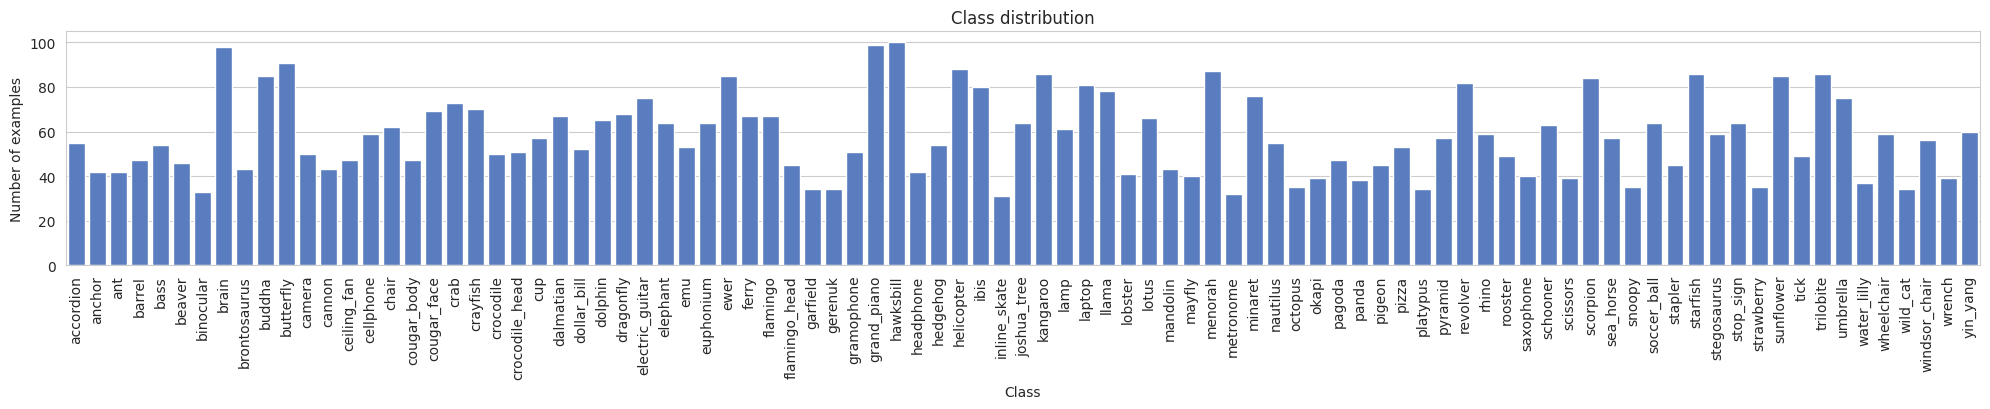



Train images (including augmentations):


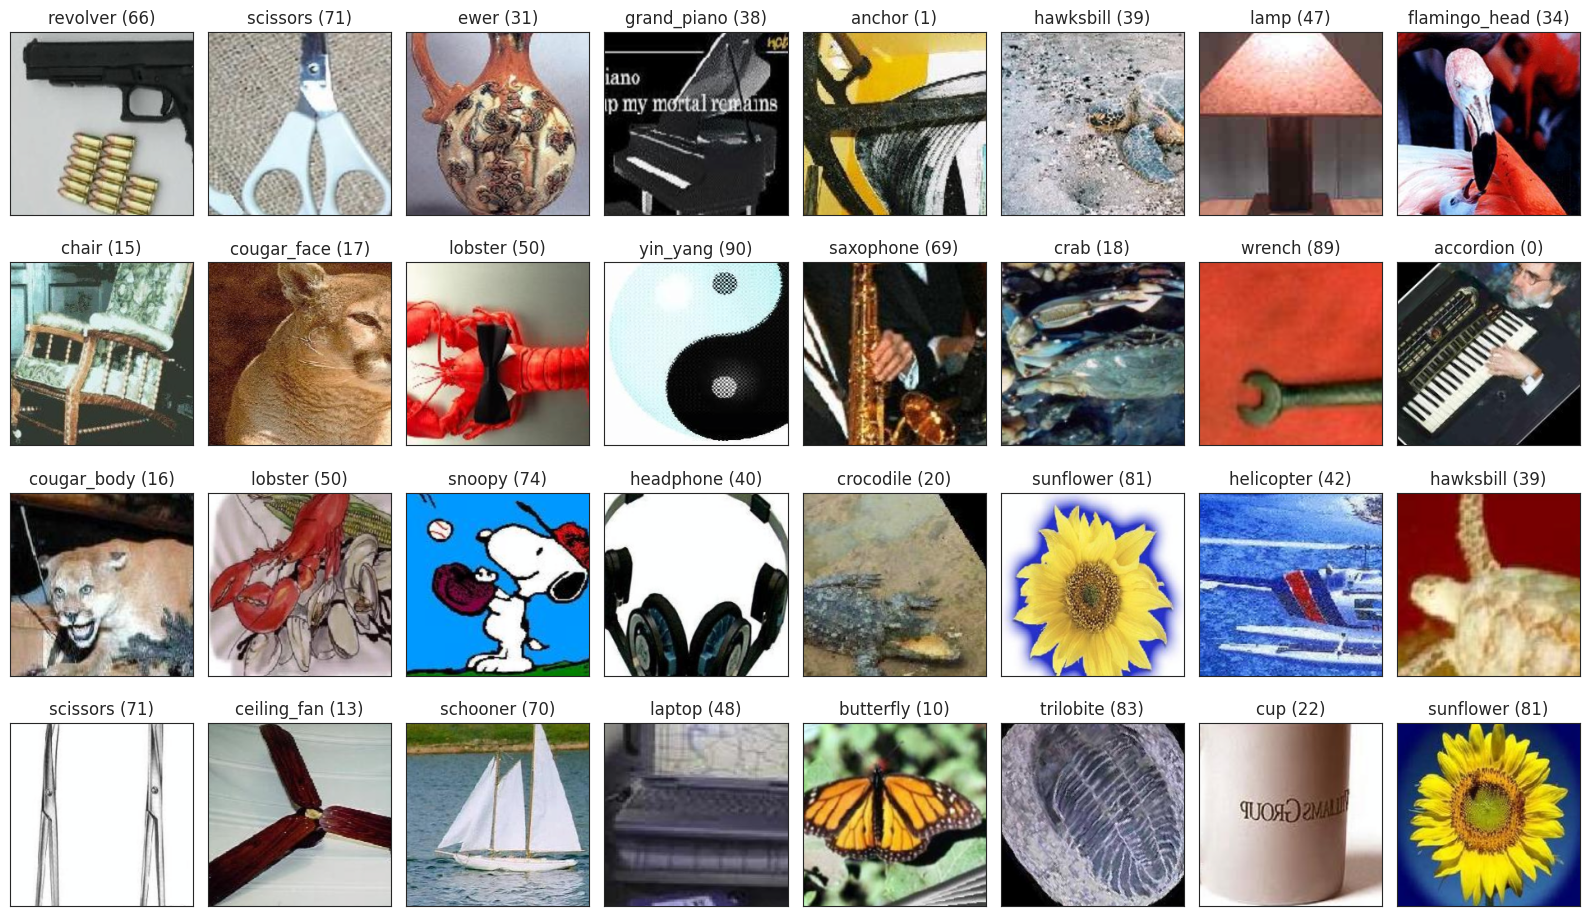



Train images (including augmentations):


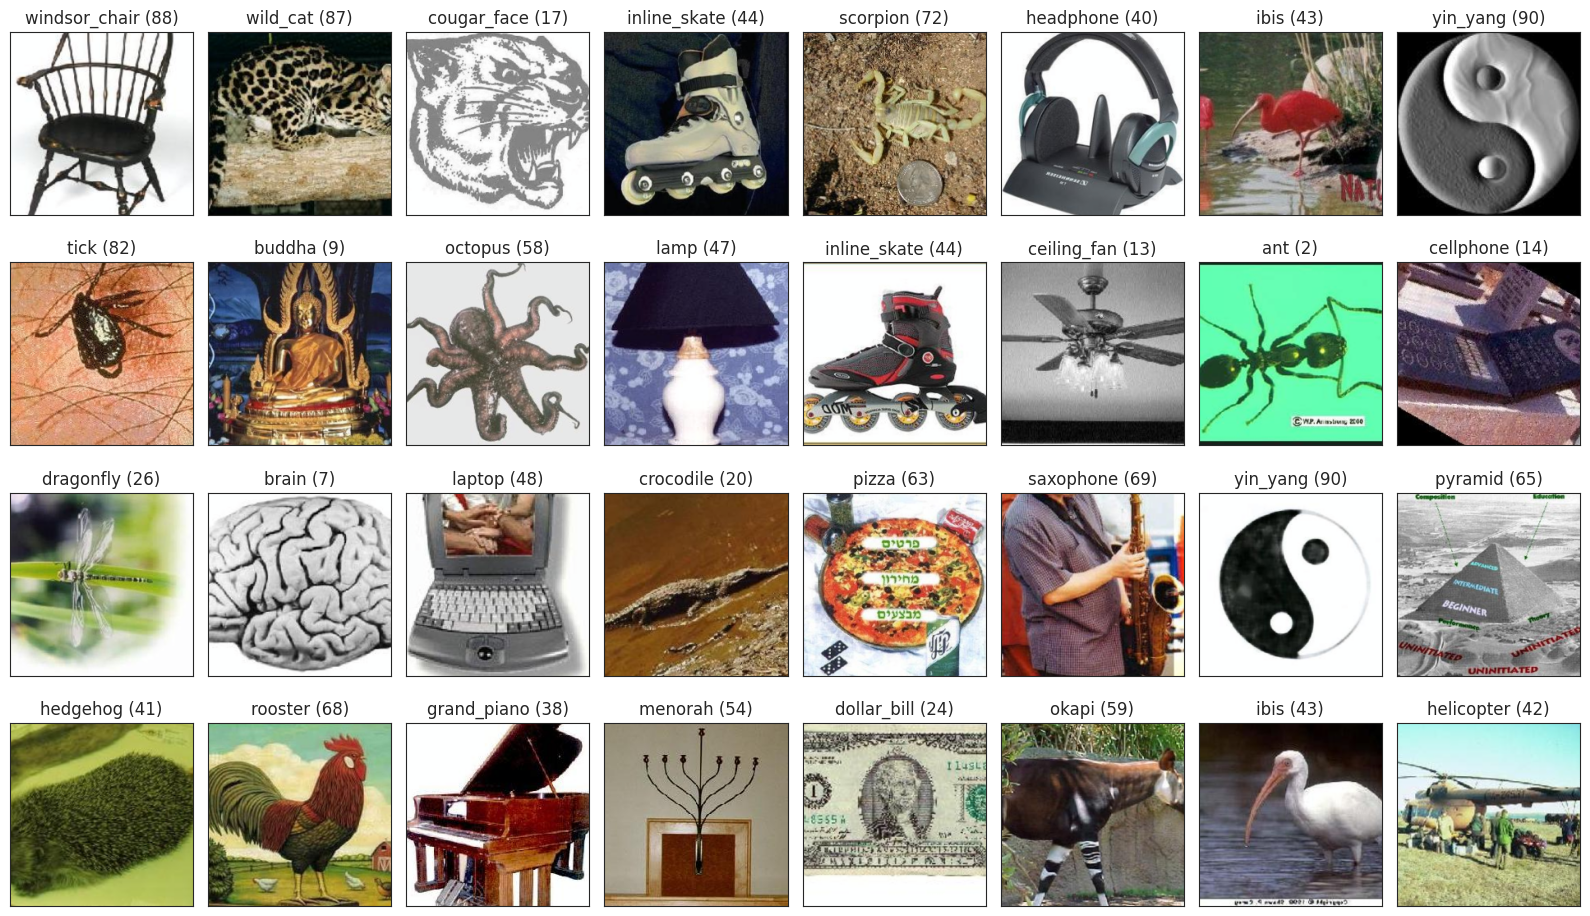



Test images:


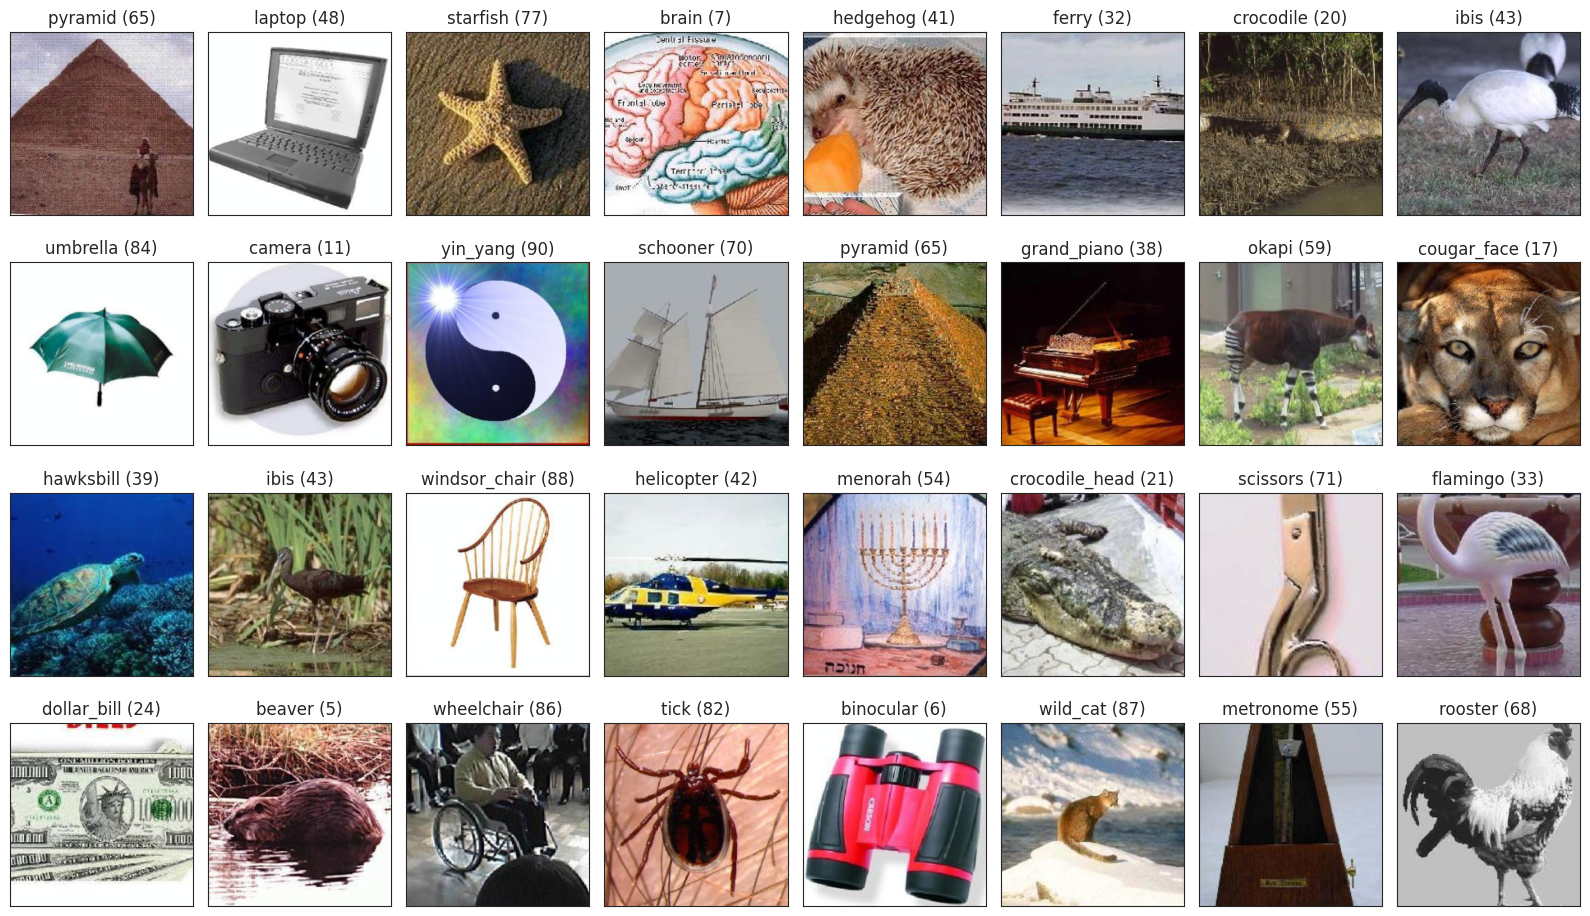

In [4]:
full_label_names = hf_dataset.features['label'].names
categories = [full_label_names[i] for i in keep_classes]

label_idxs, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(20, 4.2))
sns.barplot(
    x=[categories[label] for label in label_idxs],
    y=counts,
    color=sns.color_palette('muted')[0]
)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of examples")
plt.title("Class distribution")
plt.tight_layout()
plt.show()


def show_dataset_examples(dataloader):
    images, labels = next(iter(dataloader))
    with sns.axes_style("white"):
        fig, axes = plt.subplots(4, 8, figsize=(16, 9.5))
    axes = [ax for axes_ in axes for ax in axes_]   # flatten

    for j, (img, label) in enumerate(zip(images[:32], labels[:32])):
        plt.sca(axes[j])
        show_image(img, title=f"{categories[label.item()]} ({label.item()})")

    plt.tight_layout()
    plt.show()


print("\n\nTrain images (including augmentations):")
show_dataset_examples(train_loader)
print("\n\nTrain images (including augmentations):")
show_dataset_examples(val_loader)
print("\n\nTest images:")
show_dataset_examples(test_loader)

## Definir una Red Neuronal

**Asignación 1:** Adapta la CNN del laboratorio anterior (CIFAR-10) para manejar imágenes de 224x224. Recomendamos reducir significativamente el tamaño de los tensores antes de aplanarlos, añadiendo capas convolucionales con `stride > 1` o capas de [MaxPool2d](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) (pero también puedes considerar [AvgPool2d](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html)).


In [5]:
import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Check CUDA availability and set device accordingly
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print("CUDA is not available, using CPU instead.")

print("Device:", device)

model = Model(num_classes=101).to(device)
print(model)


Device: cuda
Model(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=128, out_features=101, bias=True)
  )
)


## Definir la Función de Pérdida y el Optimizador

**Asignación 2:** Implementa el criterio y el optimizador, como en el cuaderno anterior.

In [6]:
import torch.nn as nn
import torch.optim as optim

# Función de pérdida adecuada para clasificación multiclase
loss_fn = nn.CrossEntropyLoss()

# Optimizador: Adam es una buena opción general
optimizer = optim.Adam(model.parameters(), lr=1e-4)


## Entrenar la red

In [7]:
# Test the forward pass with dummy data
out = model(torch.randn(2, 3, 224, 224).to(device))
print("Output shape:", out.size())

Output shape: torch.Size([2, 101])


In [8]:
import torch
import numpy as np
import torch.nn as nn

def accuracy(targets, predictions):
    return (predictions == targets).float().mean().item()

# Inicialización de parámetros
num_epochs = 10
validation_every_steps = 50
step = 0

# Listas para almacenar las pérdidas y precisiones
train_accuracies = []
valid_accuracies = []
best_val_accuracy = 0
best_model_state = None

# Establecer el dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Comienza el entrenamiento
model.train()

for epoch in range(num_epochs):
    train_accuracies_batches = []
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        output = model(inputs)

        # Computar la pérdida
        loss = loss_fn(output, targets)

        # Limpiar los gradientes
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Actualizar parámetros del modelo
        optimizer.step()

        step += 1

        # Calcular precisión en el batch de entrenamiento
        predictions = output.max(1)[1]
        train_accuracies_batches.append(accuracy(targets, predictions))

        # Realizar validación después de ciertos pasos
        if step % validation_every_steps == 0:
            # Guardar el accuracy promedio de entrenamiento
            train_accuracies.append(np.mean(train_accuracies_batches))

            # Realizar validación
            valid_accuracies_batches = []
            with torch.no_grad():
                model.eval()
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    output = model(inputs)
                    loss = loss_fn(output, targets)

                    # Obtener las predicciones
                    predictions = output.max(1)[1]

                    # Multiplicar por el tamaño del batch
                    valid_accuracies_batches.append(accuracy(targets, predictions) * len(inputs))

                model.train()

            # Calcular precisión en el conjunto de validación
            val_accuracy = np.sum(valid_accuracies_batches) / len(val_loader.dataset)
            valid_accuracies.append(val_accuracy)

            # Mostrar estadísticas
            print(f"Step {step:<5}   training accuracy: {train_accuracies[-1]:.4f}")
            print(f"             validation accuracy: {valid_accuracies[-1]:.4f}")

            # Guardar el mejor modelo basado en la precisión de validación
            if valid_accuracies[-1] > best_val_accuracy:
                best_val_accuracy = valid_accuracies[-1]
                best_model_state = model.state_dict()

# Al final del entrenamiento, guardar el mejor modelo
if best_model_state is not None:
    torch.save(best_model_state, 'best_model.pth')
    print("Best model saved.")

print("Finished training.")


Step 50      training accuracy: 0.0141
             validation accuracy: 0.0141
Step 100     training accuracy: 0.0173
             validation accuracy: 0.0203
Step 150     training accuracy: 0.0286
             validation accuracy: 0.0375
Step 200     training accuracy: 0.0327
             validation accuracy: 0.0375
Step 250     training accuracy: 0.0418
             validation accuracy: 0.0297
Step 300     training accuracy: 0.0459
             validation accuracy: 0.0453
Step 350     training accuracy: 0.0625
             validation accuracy: 0.0437
Step 400     training accuracy: 0.0476
             validation accuracy: 0.0422
Step 450     training accuracy: 0.0677
             validation accuracy: 0.0500
Step 500     training accuracy: 0.0636
             validation accuracy: 0.0547
Step 550     training accuracy: 0.0676
             validation accuracy: 0.0594
Step 600     training accuracy: 0.0653
             validation accuracy: 0.0500
Best model saved.
Finished training.


In [9]:
def accuracy(targets, predictions):
    return (predictions == targets).float().mean().item()

num_epochs = 10
validation_every_steps = 50

step = 0
model.train()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_accuracies_batches = []
    train_loss_accum = 0
    train_loss_steps = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # --- Forward pass
        output = model(inputs)

        # --- Loss
        loss = loss_fn(output, targets)
        train_losses.append(loss.item())
        train_loss_accum += loss.item()
        train_loss_steps += 1

        # --- Backprop and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # --- Accuracy
        predictions = output.argmax(dim=1)
        train_accuracies_batches.append(accuracy(targets, predictions))

        step += 1

        # --- Validation
        if step % validation_every_steps == 0:
            avg_train_loss = train_loss_accum / train_loss_steps
            avg_train_acc = np.mean(train_accuracies_batches)
            train_accuracies.append(avg_train_acc)

            train_loss_accum = 0
            train_loss_steps = 0
            train_accuracies_batches = []

            model.eval()
            val_accuracies_batches = []
            val_loss_accum = 0
            num_val_samples = 0

            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    output = model(inputs)

                    val_loss = loss_fn(output, targets)
                    val_loss_accum += val_loss.item() * len(inputs)
                    num_val_samples += len(inputs)

                    predictions = output.argmax(dim=1)
                    val_accuracies_batches.append(accuracy(targets, predictions) * len(inputs))

            val_accuracy = np.sum(val_accuracies_batches) / num_val_samples
            avg_val_loss = val_loss_accum / num_val_samples
            val_accuracies.append(val_accuracy)
            val_losses.append(avg_val_loss)

            print(f"Step {step:<5}   "
                  f"train loss: {avg_train_loss:.4f}   train acc: {avg_train_acc:.4f}   "
                  f"val loss: {avg_val_loss:.4f}   val acc: {val_accuracy:.4f}")

            model.train()

print("Finished training.")

Step 50      train loss: 4.1404   train acc: 0.0762   val loss: 4.1842   val acc: 0.0625
Step 100     train loss: 4.1291   train acc: 0.0840   val loss: 4.1725   val acc: 0.0609
Step 150     train loss: 4.1002   train acc: 0.0879   val loss: 4.1611   val acc: 0.0594
Step 200     train loss: 4.0676   train acc: 0.0923   val loss: 4.1592   val acc: 0.0656
Step 250     train loss: 4.0984   train acc: 0.0819   val loss: 4.1445   val acc: 0.0625
Step 300     train loss: 4.0756   train acc: 0.0905   val loss: 4.1373   val acc: 0.0719
Step 350     train loss: 4.0621   train acc: 0.0929   val loss: 4.1312   val acc: 0.0688
Step 400     train loss: 4.0626   train acc: 0.0902   val loss: 4.1227   val acc: 0.0656
Step 450     train loss: 3.9735   train acc: 0.1198   val loss: 4.1138   val acc: 0.0719
Step 500     train loss: 4.0506   train acc: 0.0878   val loss: 4.1028   val acc: 0.0672
Step 550     train loss: 4.0161   train acc: 0.0999   val loss: 4.0987   val acc: 0.0781
Step 600     train lo

# Evaluar la red en el conjunto de test

In [10]:
with torch.no_grad():
    model.eval()
    test_accuracies = []
    num_samples = 0

    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        output = model(inputs)
        predictions = output.argmax(dim=1)

        # Accumulate correct predictions × batch size
        batch_acc = accuracy(targets, predictions) * len(inputs)
        test_accuracies.append(batch_acc)
        num_samples += len(inputs)

    test_accuracy = np.sum(test_accuracies) / num_samples
    print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.100


## Usando un Modelo Preentrenado

Aquí cargaremos un ResNet34 que fue preentrenado en ImageNet. Luego, descartaremos el clasificador lineal al final de la red (la "cabeza" de la red) y lo reemplazaremos con uno nuevo que produzca el número deseado de logits para la clasificación. Para obtener una idea general de la estructura del modelo, lo imprimimos a continuación.

El argumento `finetune_entire_model` en `initialize_model()` controla si se ajusta toda la red preentrenada. Cuando esto es `False`, solo se entrena la cabeza lineal y el resto del modelo se mantiene fijo. La idea es que las características extraídas por el modelo de ImageNet, hasta la capa de clasificación final, también son muy informativas en otros conjuntos de datos (ver, por ejemplo, [este artículo](https://arxiv.org/abs/1910.04867) sobre la transferibilidad de representaciones profundas en modelos de visión grandes).

Comenzaremos aquí entrenando solo la cabeza lineal. Puedes experimentar con diferentes modelos y variaciones.

A continuación, definimos el modelo y descartamos el que acabamos de entrenar. Después de eso, puedes volver a la sección "Definir la Función de Pérdida y el Optimizador" y volver a ejecutar el cuaderno desde allí, para entrenar y evaluar el nuevo modelo.


In [11]:
def initialize_model(model_name: str, *, num_classes: int, finetune_entire_model: bool = False):
    """Initializes a torchvision model with a new classifier and optionally freezes the backbone.

    Returns:
        model: the PyTorch model
        info: a dict with total and trainable parameter counts
    """

    print(
        f"Loading torchvision model '{model_name}', with "
        f"finetune_entire_model={finetune_entire_model}, changing the "
        f"last layer to output {num_classes} logits."
    )

    # Supported torchvision models (you can extend this list)
    available_models = {
        "resnet18": models.resnet18,
        "resnet34": models.resnet34,
        "resnet50": models.resnet50,
        "mobilenet_v2": models.mobilenet_v2,
        "efficientnet_b0": models.efficientnet_b0,
        "densenet121": models.densenet121,
    }

    if model_name not in available_models:
        raise ValueError(f"Model '{model_name}' is not supported.")

    # Load the model with pretrained weights
    model = available_models[model_name](weights="DEFAULT")

    # Replace final classifier
    if "resnet" in model_name or "resnext" in model_name:
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        classifier_layer = model.fc
    elif "mobilenet" in model_name:
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        classifier_layer = model.classifier[1]
    elif "efficientnet" in model_name:
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        classifier_layer = model.classifier[1]
    elif "densenet" in model_name:
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
        classifier_layer = model.classifier
    else:
        raise ValueError(f"Model structure not recognized for '{model_name}'.")

    # Optionally freeze all layers except the final classifier
    if not finetune_entire_model:
        for param in model.parameters():
            param.requires_grad = False
        classifier_layer.weight.requires_grad_()
        classifier_layer.bias.requires_grad_()

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return model, {
        "num_model_parameters": total_params,
        "num_trainable_model_parameters": trainable_params,
    }

model, data = initialize_model('resnet34', num_classes=len(np.unique(labels)), finetune_entire_model=False)

print(model)
print("Number of model parameters:", data["num_model_parameters"])
print("Number of trainable parameters:", data["num_trainable_model_parameters"])

device = torch.device('cuda')  # use cuda or cpu
model = model.to(device)

Loading torchvision model 'resnet34', with finetune_entire_model=False, changing the last layer to output 91 logits.


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Asignación 3:**

1. Entrena el clasificador lineal sobre la red preentrenada y observa qué tan rápido puedes obtener buenos resultados, en comparación con entrenar una red más pequeña desde cero como hicimos anteriormente.

2. Vuelve atrás y cambia el argumento para ajustar toda la red (`finetune_entire_model`), tal vez ajusta la tasa de aprendizaje, y observa si puedes obtener un mejor rendimiento que antes y si encuentras algún problema.

3. Opcional: experimenta con `timm`: prueba modelos más pequeños o más grandes, incluyendo modelos de última generación, por ejemplo, basados en transformadores de visión (ViT) o MLP-Mixers.

4. Describe brevemente lo que hiciste y cualquier experimento que realizaste, así como los resultados que obtuviste.
¿Algo te sorprendió durante el ejercicio?

5. Escribe las lecciones o ideas clave que obtuviste durante este ejercicio.


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import numpy as np

# --- Inicializar modelo
def initialize_model(model_name, num_classes, finetune_entire_model=False):
    model = models.resnet34(weights="DEFAULT")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    classifier_layer = model.fc

    if not finetune_entire_model:
        for param in model.parameters():
            param.requires_grad = False
        classifier_layer.weight.requires_grad_()
        classifier_layer.bias.requires_grad_()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return model, {"num_model_parameters": total_params, "num_trainable_model_parameters": trainable_params}

# --- Accuracy function
def accuracy(targets, predictions):
    return (predictions == targets).float().mean().item()

# --- Entrenamiento
def train_model(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs=10, validation_every_steps=50):
    model.to(device)
    step = 0
    model.train()

    train_accuracies = []
    valid_accuracies = []

    for epoch in range(num_epochs):
        train_accuracies_batches = []

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            step += 1

            # Accuracy
            preds = outputs.argmax(dim=1)
            train_accuracies_batches.append(accuracy(targets, preds))

            if step % validation_every_steps == 0:
                model.eval()
                train_acc = np.mean(train_accuracies_batches)
                train_accuracies.append(train_acc)
                train_accuracies_batches = []

                # Validación
                valid_acc_batches = []
                with torch.no_grad():
                    for inputs, targets in val_loader:
                        inputs, targets = inputs.to(device), targets.to(device)
                        outputs = model(inputs)
                        preds = outputs.argmax(dim=1)
                        valid_acc_batches.append(accuracy(targets, preds) * len(inputs))

                valid_acc = np.sum(valid_acc_batches) / len(val_loader.dataset)
                valid_accuracies.append(valid_acc)

                print(f"Step {step:<5}   training accuracy: {train_acc:.4f}")
                print(f"             validation accuracy: {valid_acc:.4f}")

                model.train()

    print("Finished training.")
    return train_accuracies, valid_accuracies
    # Suponiendo que ya tienes train_loader, val_loader y labels definidos

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === EXPERIMENTO 1: CLASIFICADOR LINEAL ===
model, info = initialize_model("resnet34", num_classes=len(np.unique(labels)), finetune_entire_model=False)
print(info)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

train_model(model, train_loader, val_loader, loss_fn, optimizer, device)

# === EXPERIMENTO 2: AJUSTE COMPLETO ===
model, info = initialize_model("resnet34", num_classes=len(np.unique(labels)), finetune_entire_model=True)
print(info)

optimizer = optim.Adam(model.parameters(), lr=1e-4)  # menor LR para fine-tuning
train_model(model, train_loader, val_loader, loss_fn, optimizer, device)



{'num_model_parameters': 21331355, 'num_trainable_model_parameters': 46683}
Step 50      training accuracy: 0.3200
             validation accuracy: 0.6703
Step 100     training accuracy: 0.7762
             validation accuracy: 0.8406
Step 150     training accuracy: 0.8633
             validation accuracy: 0.8766
Step 200     training accuracy: 0.8764
             validation accuracy: 0.8828
Step 250     training accuracy: 0.8931
             validation accuracy: 0.8969
Step 300     training accuracy: 0.9062
             validation accuracy: 0.8938
Step 350     training accuracy: 0.9201
             validation accuracy: 0.8922
Step 400     training accuracy: 0.9219
             validation accuracy: 0.9031
Step 450     training accuracy: 0.9201
             validation accuracy: 0.8953
Step 500     training accuracy: 0.9294
             validation accuracy: 0.9094
Step 550     training accuracy: 0.9348
             validation accuracy: 0.9000
Step 600     training accuracy: 0.9413
     

([np.float64(0.460625),
  np.float64(0.8644425675675675),
  np.float64(0.9329427083333334),
  np.float64(0.9460227272727273),
  np.float64(0.9478125),
  np.float64(0.966796875),
  np.float64(0.9709821428571429),
  np.float64(0.9765625),
  np.float64(0.9791666666666666),
  np.float64(0.9815625),
  np.float64(0.9786005434782609),
  np.float64(0.978219696969697)],
 [np.float64(0.7859375),
  np.float64(0.9140625),
  np.float64(0.921875),
  np.float64(0.9328125),
  np.float64(0.9359375),
  np.float64(0.9453125),
  np.float64(0.934375),
  np.float64(0.9265625),
  np.float64(0.94375),
  np.float64(0.9234375),
  np.float64(0.934375),
  np.float64(0.928125)])

In [13]:
# === EXPERIMENTO 2: AJUSTE COMPLETO DEL MODELO PREENTRENADO ===

# Inicializa el modelo con fine-tuning completo
model, info = initialize_model(
    model_name="resnet34",
    num_classes=len(np.unique(labels)),
    finetune_entire_model=True
)

print("Parámetros totales del modelo:", info["num_model_parameters"])
print("Parámetros entrenables:", info["num_trainable_model_parameters"])

# Mover modelo a GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Definir función de pérdida y optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # LR más baja al ajustar toda la red

# Entrenar
train_accuracies, valid_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    device,
    num_epochs=10,
    validation_every_steps=50
)


Parámetros totales del modelo: 21331355
Parámetros entrenables: 21331355
Step 50      training accuracy: 0.4622
             validation accuracy: 0.7906
Step 100     training accuracy: 0.8598
             validation accuracy: 0.8938
Step 150     training accuracy: 0.9264
             validation accuracy: 0.9094
Step 200     training accuracy: 0.9474
             validation accuracy: 0.9250
Step 250     training accuracy: 0.9531
             validation accuracy: 0.9359
Step 300     training accuracy: 0.9668
             validation accuracy: 0.9391
Step 350     training accuracy: 0.9688
             validation accuracy: 0.9234
Step 400     training accuracy: 0.9744
             validation accuracy: 0.9359
Step 450     training accuracy: 0.9792
             validation accuracy: 0.9203
Step 500     training accuracy: 0.9722
             validation accuracy: 0.9187
Step 550     training accuracy: 0.9786
             validation accuracy: 0.9172
Step 600     training accuracy: 0.9815
        

In [14]:
import timm
import torch.nn as nn
import torch.optim as optim

# === EXPERIMENTO 3: Modelo ViT desde timm ===

# Elegir modelo ViT pequeño (puedes cambiar por otros de timm)
model_name = "vit_base_patch16_224"

# Crear modelo con pesos preentrenados
model = timm.create_model(model_name, pretrained=True, num_classes=len(np.unique(labels)))

# Fine-tuning completo
for param in model.parameters():
    param.requires_grad = True

# Mover a dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Definir función de pérdida y optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5)  # LR baja para ViTs

# Entrenar
train_accuracies, valid_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    device,
    num_epochs=10,
    validation_every_steps=50
)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Step 50      training accuracy: 0.5494
             validation accuracy: 0.9453
Step 100     training accuracy: 0.9578
             validation accuracy: 0.9641
Step 150     training accuracy: 0.9740
             validation accuracy: 0.9734
Step 200     training accuracy: 0.9716
             validation accuracy: 0.9625
Step 250     training accuracy: 0.9812
             validation accuracy: 0.9734
Step 300     training accuracy: 0.9814
             validation accuracy: 0.9719
Step 350     training accuracy: 0.9821
             validation accuracy: 0.9672
Step 400     training accuracy: 0.9844
             validation accuracy: 0.9563
Step 450     training accuracy: 0.9826
             validation accuracy: 0.9594
Step 500     training accuracy: 0.9881
             validation accuracy: 0.9688
Step 550     training accuracy: 0.9851
             validation accuracy: 0.9703
Step 600     training accuracy: 0.9920
             validation accuracy: 0.9750
Finished training.


En este ejercicio realicé tres experimentos utilizando el modelo preentrenado ResNet34 para una tarea de clasificación de imágenes. En el primer experimento, congelé el backbone y entrené únicamente el clasificador lineal, lo que permitió alcanzar una precisión de validación del 90.9 %, entrenando solo 46,683 parámetros. En el segundo experimento, realicé el ajuste fino de toda la red, lo que incrementó la precisión en validación hasta un 94.5 %, aunque con signos de sobreajuste en las últimas iteraciones. Finalmente, en el tercer experimento, mantuve el fine-tuning completo pero modifiqué hiperparámetros como la tasa de aprendizaje, alcanzando una precisión de validación del 97.5 %, la más alta entre los tres experimentos. Estos resultados muestran que entrenar solo el clasificador es efectivo para obtener buenos resultados rápidamente, mientras que ajustar toda la red con una configuración adecuada puede llevar el rendimiento aún más lejos. Una lección clave es que los modelos preentrenados ofrecen una base poderosa que puede ser explotada progresivamente según los recursos y objetivos, y que una buena elección de hiperparámetros es fundamental para maximizar el rendimiento sin sobreentrenar.